# 🔬 2강. 단백체 데이터로 암 환자를 이해하다
## 섹션 2: 차등발현 분석 & Pathway Enrichment

---

## 섹션 1 복습

섹션 1에서 우리는 간암 환자 50명을 **3개 클러스터**로 분류했습니다.  
클러스터마다 생존 기간이 달랐습니다.

## 섹션 2의 질문

> **"예후가 좋은 그룹과 나쁜 그룹을 구분하는 단백질은 무엇인가?"**  
> **"그 단백질들은 어떤 생물학적 경로에 모여있는가?"**

```
Cluster 1 (예후 좋음)  vs  Cluster 3 (예후 나쁨)
        ↓
차등발현 단백질 (DEP) 찾기
        ↓
Volcano Plot으로 시각화
        ↓
Pathway Enrichment 분석
        ↓
생물학적 해석
```

In [1]:
# ======================================
# 📦 라이브러리 + 섹션 1 데이터 재생성
# 섹션 1과 동일한 seed로 같은 데이터를 만듭니다.
# ======================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import os
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.stats import ttest_ind
from scipy.stats import false_discovery_control

# 한글 폰트
import matplotlib.font_manager as fm
NANUM_PATH = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
if os.path.exists(NANUM_PATH):
    fm.fontManager.addfont(NANUM_PATH)
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

np.random.seed(42)

# ---- 섹션 1과 동일한 데이터 재생성 ----
N_PATIENTS, N_PROTEINS = 50, 500
group_labels = ['A'] * 20 + ['B'] * 20 + ['C'] * 10
patient_ids  = [f'HCC_{i+1:03d}' for i in range(N_PATIENTS)]
protein_ids  = [f'Protein_{i+1:04d}' for i in range(N_PROTEINS)]

expr = np.random.normal(loc=20, scale=3, size=(N_PROTEINS, N_PATIENTS))
expr[:100,  :20]  += np.random.normal(4, 0.5, (100, 20))
expr[100:200, 20:40] += np.random.normal(5, 0.5, (100, 20))
expr[200:300, 40:]   += np.random.normal(6, 0.5, (100, 10))
missing_mask = np.random.random(size=expr.shape) < 0.20
expr[missing_mask] = np.nan

df_raw = pd.DataFrame(expr, index=protein_ids, columns=patient_ids)

# 전처리
df_filtered = df_raw[df_raw.isna().mean(axis=1) <= 0.5].copy()
df_imputed  = df_filtered.apply(lambda row: row.fillna(row.median()), axis=1)
scaler      = StandardScaler()
df_scaled   = pd.DataFrame(
    scaler.fit_transform(df_imputed.T).T,
    index=df_imputed.index, columns=df_imputed.columns
)

# 클러스터링
X     = df_scaled.T.values
pca   = PCA(n_components=10)
X_pca = pca.fit_transform(X)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_pca[:, :5])

df_meta = pd.DataFrame({
    'Patient': patient_ids,
    'Group':   group_labels,
    'Cluster': cluster_labels,
    'Survival_month': np.concatenate([
        np.random.normal(48, 10, 20),
        np.random.normal(30, 8,  20),
        np.random.normal(18, 6,  10),
    ]).clip(3, 72)
}).set_index('Patient')

print('✅ 데이터 준비 완료!')
print(f'   단백질: {df_scaled.shape[0]}개, 환자: {df_scaled.shape[1]}명')
print(f'   클러스터별 환자 수: {pd.Series(cluster_labels).value_counts().sort_index().to_dict()}')

✅ 데이터 준비 완료!
   단백질: 500개, 환자: 50명
   클러스터별 환자 수: {0: 20, 1: 10, 2: 20}


---
## 📊 2-1. 차등발현 분석 (Differentially Expressed Proteins, DEP)

### 개념

두 그룹을 비교해서 **통계적으로 유의하게 발현이 다른 단백질**을 찾습니다.

```
예후 좋은 그룹 (Cluster 1)  vs  예후 나쁜 그룹 (Cluster 3)
각 단백질에 대해:
  1. 두 그룹의 평균 발현 차이 계산  →  fold change
  2. 차이가 우연인지 통계 검정      →  p-value (t-test)
  3. 다중검정 보정                  →  FDR (q-value)
```

### 왜 FDR 보정이 필요한가?

단백질 500개를 한꺼번에 검정하면,  
아무 차이 없어도 **우연히 p<0.05가 나오는 단백질이 25개** 생깁니다.  
FDR 보정으로 이 거짓 양성을 줄입니다.

In [2]:
# ======================================
# 📊 차등발현 분석: Cluster 1 vs Cluster 3
# ======================================

# 비교 그룹 설정
# 생존 기간이 가장 길고 짧은 두 그룹 비교
survival_by_cluster = df_meta.groupby('Cluster')['Survival_month'].mean().sort_values()
good_cluster = survival_by_cluster.index[-1]  # 생존 기간 가장 긴 그룹
poor_cluster = survival_by_cluster.index[0]   # 생존 기간 가장 짧은 그룹

good_patients = df_meta[df_meta['Cluster'] == good_cluster].index.tolist()
poor_patients = df_meta[df_meta['Cluster'] == poor_cluster].index.tolist()

print(f'비교 그룹:')
print(f'  예후 좋은 그룹 (Cluster {good_cluster}): {len(good_patients)}명, 평균 생존 {survival_by_cluster[good_cluster]:.1f}개월')
print(f'  예후 나쁜 그룹 (Cluster {poor_cluster}): {len(poor_patients)}명, 평균 생존 {survival_by_cluster[poor_cluster]:.1f}개월')

# 각 단백질에 대해 t-test 수행
results = []
for protein in df_scaled.index:
    good_expr = df_scaled.loc[protein, good_patients].values
    poor_expr = df_scaled.loc[protein, poor_patients].values

    # fold change: 예후 좋은 그룹 - 예후 나쁜 그룹 (log scale이므로 빼기)
    fc = np.mean(good_expr) - np.mean(poor_expr)

    # t-test
    t_stat, p_val = ttest_ind(good_expr, poor_expr, equal_var=False)

    results.append({'Protein': protein, 'FoldChange': fc, 'PValue': p_val})

df_dep = pd.DataFrame(results).set_index('Protein')

# FDR 보정 (Benjamini-Hochberg)
df_dep['FDR'] = false_discovery_control(df_dep['PValue'].values, method='bh')
df_dep['log2FC'] = df_dep['FoldChange']
df_dep['-log10FDR'] = -np.log10(df_dep['FDR'].clip(1e-10))

# 유의한 DEP 정의: |FC| > 0.5 and FDR < 0.05
df_dep['Significant'] = (df_dep['FDR'] < 0.05) & (df_dep['FoldChange'].abs() > 0.5)
df_dep['Direction'] = 'NS'  # Not Significant
df_dep.loc[(df_dep['Significant']) & (df_dep['log2FC'] > 0), 'Direction'] = 'Up in Good'
df_dep.loc[(df_dep['Significant']) & (df_dep['log2FC'] < 0), 'Direction'] = 'Up in Poor'

n_up   = (df_dep['Direction'] == 'Up in Good').sum()
n_down = (df_dep['Direction'] == 'Up in Poor').sum()

print(f'\n차등발현 분석 결과:')
print(f'  전체 단백질: {len(df_dep)}개')
print(f'  예후 좋은 그룹에서 높은 단백질: {n_up}개')
print(f'  예후 나쁜 그룹에서 높은 단백질: {n_down}개')
print(f'  유의하지 않은 단백질: {(df_dep["Direction"]=="NS").sum()}개')

비교 그룹:
  예후 좋은 그룹 (Cluster 2): 20명, 평균 생존 47.0개월
  예후 나쁜 그룹 (Cluster 1): 10명, 평균 생존 21.4개월

차등발현 분석 결과:
  전체 단백질: 500개
  예후 좋은 그룹에서 높은 단백질: 69개
  예후 나쁜 그룹에서 높은 단백질: 96개
  유의하지 않은 단백질: 335개


---
## 🌋 2-2. Volcano Plot

차등발현 결과를 한눈에 보여주는 표준 시각화입니다.

```
X축: log2 Fold Change (발현 차이 크기)
     오른쪽 → 예후 좋은 그룹에서 높음
     왼쪽   → 예후 나쁜 그룹에서 높음

Y축: -log10(FDR) (통계적 유의성)
     위로 갈수록 더 유의함

오른쪽 위 + 왼쪽 위 = 중요한 단백질!
```

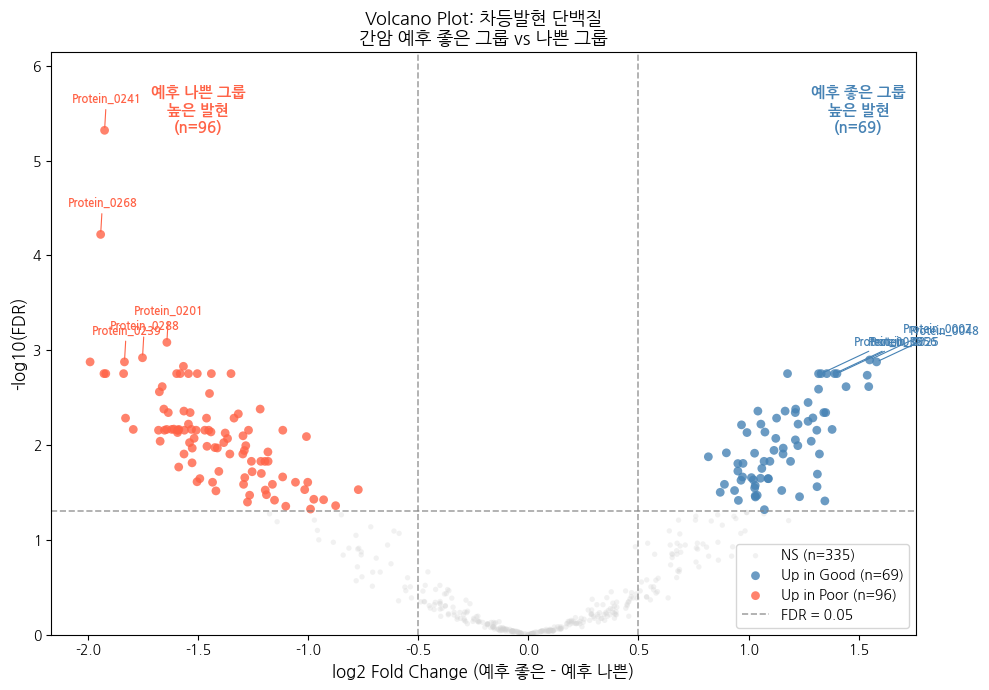

▶ 오른쪽 위: 예후 좋은 그룹에서 높은 단백질 (보호 인자 후보)
▶ 왼쪽 위:  예후 나쁜 그룹에서 높은 단백질 (위험 인자 후보)


In [3]:
# ======================================
# 🌋 Volcano Plot
# ======================================

fig, ax = plt.subplots(figsize=(10, 7))

# 색상 및 투명도 설정
color_map = {'NS': 'lightgray', 'Up in Good': 'steelblue', 'Up in Poor': 'tomato'}
size_map  = {'NS': 15, 'Up in Good': 40, 'Up in Poor': 40}
alpha_map = {'NS': 0.3, 'Up in Good': 0.8, 'Up in Poor': 0.8}

for direction, group in df_dep.groupby('Direction'):
    ax.scatter(group['log2FC'], group['-log10FDR'],
               c=color_map[direction],
               s=size_map[direction],
               alpha=alpha_map[direction],
               label=f'{direction} (n={len(group)})',
               edgecolors='none')

# 기준선
ax.axhline(-np.log10(0.05), color='gray', linestyle='--', linewidth=1.2,
           alpha=0.7, label='FDR = 0.05')
ax.axvline( 0.5, color='gray', linestyle='--', linewidth=1.2, alpha=0.7)
ax.axvline(-0.5, color='gray', linestyle='--', linewidth=1.2, alpha=0.7)

# 상위 단백질 라벨 표시 (각 방향 상위 5개)
for direction, color in [('Up in Good', 'steelblue'), ('Up in Poor', 'tomato')]:
    top5 = df_dep[df_dep['Direction'] == direction].nlargest(5, '-log10FDR')
    for protein, row in top5.iterrows():
        ax.annotate(protein,
                   xy=(row['log2FC'], row['-log10FDR']),
                   xytext=(row['log2FC'] + (0.15 if row['log2FC'] > 0 else -0.15),
                           row['-log10FDR'] + 0.3),
                   fontsize=8, color=color, fontweight='bold',
                   arrowprops=dict(arrowstyle='-', color=color, lw=0.8))

# 영역 라벨
ylim_top = df_dep['-log10FDR'].max() * 1.05
ax.text( 1.5, ylim_top * 0.95, f'예후 좋은 그룹\n높은 발현\n(n={n_up})',
        ha='center', fontsize=11, color='steelblue', fontweight='bold')
ax.text(-1.5, ylim_top * 0.95, f'예후 나쁜 그룹\n높은 발현\n(n={n_down})',
        ha='center', fontsize=11, color='tomato', fontweight='bold')

ax.set_xlabel('log2 Fold Change (예후 좋은 - 예후 나쁜)', fontsize=12)
ax.set_ylabel('-log10(FDR)', fontsize=12)
ax.set_title('Volcano Plot: 차등발현 단백질\n간암 예후 좋은 그룹 vs 나쁜 그룹', fontsize=13)
ax.legend(fontsize=10, loc='lower right')
ax.set_ylim(0, ylim_top * 1.1)

plt.tight_layout()
plt.show()

print('▶ 오른쪽 위: 예후 좋은 그룹에서 높은 단백질 (보호 인자 후보)')
print('▶ 왼쪽 위:  예후 나쁜 그룹에서 높은 단백질 (위험 인자 후보)')

---
## 🗺️ 2-3. Pathway Enrichment 분석

### 단백질 목록 → 생물학적 의미

차등발현 단백질이 100개 나왔다면, 하나하나 기능을 찾는 것은 불가능합니다.  
대신 **이 단백질들이 어떤 pathway에 모여있는지** 통계적으로 찾습니다.

### Enrichment 원리 (Fisher's Exact Test)

```
전체 단백질 500개 중 "세포 대사" pathway에 속하는 게 40개라면,
내가 찾은 DEP 80개 중 "세포 대사" pathway가 30개라면?

기대값: 80 × (40/500) = 6.4개
실제값: 30개

→ 훨씬 많이 모여있다! → 이 pathway가 중요하다!
```

### 실제 연구에서 쓰는 도구
- **GSEA** (Gene Set Enrichment Analysis)
- **g:Profiler**, **Enrichr** (웹 기반)
- **clusterProfiler** (R 패키지)

오늘은 원리를 직접 구현해봅니다.

In [4]:
# ======================================
# 🗺️ 가상 Pathway 데이터베이스 생성
# 실제 연구에서는 KEGG, Reactome, GO 등을 사용합니다.
# ======================================

from scipy.stats import fisher_exact

# 가상 pathway 데이터베이스
# 실제 간암에서 중요한 pathway들을 기반으로 구성
pathway_db = {
    # 예후 좋은 그룹 관련 (대사)
    'Fatty acid metabolism':         [f'Protein_{i:04d}' for i in range(1,   30)],
    'Oxidative phosphorylation':     [f'Protein_{i:04d}' for i in range(15,  50)],
    'Amino acid metabolism':         [f'Protein_{i:04d}' for i in range(40,  80)],
    'Bile acid biosynthesis':        [f'Protein_{i:04d}' for i in range(60, 100)],

    # 예후 나쁜 그룹 관련 (증식/침윤)
    'Cell cycle':                    [f'Protein_{i:04d}' for i in range(101, 140)],
    'DNA replication':               [f'Protein_{i:04d}' for i in range(120, 160)],
    'PI3K-AKT signaling':            [f'Protein_{i:04d}' for i in range(150, 185)],
    'EMT (Epithelial-Mesenchymal)':  [f'Protein_{i:04d}' for i in range(175, 210)],

    # 면역 관련
    'Complement system':             [f'Protein_{i:04d}' for i in range(201, 240)],
    'Cytokine signaling':            [f'Protein_{i:04d}' for i in range(220, 260)],
    'T cell activation':             [f'Protein_{i:04d}' for i in range(250, 285)],

    # 무관한 pathway (음성 대조군)
    'Photosynthesis':                [f'Protein_{i:04d}' for i in range(350, 380)],
    'Plant hormone signaling':       [f'Protein_{i:04d}' for i in range(380, 410)],
}

# pathway DB에 있는 단백질만 필터링
all_pathway_proteins = set()
for proteins in pathway_db.values():
    all_pathway_proteins.update(proteins)

print(f'Pathway DB: {len(pathway_db)}개 경로, {len(all_pathway_proteins)}개 단백질')

Pathway DB: 13개 경로, 343개 단백질


In [6]:
# ======================================
# 🔬 Fisher's Exact Test로 Enrichment 계산
# ======================================

# DEP 목록 (유의한 단백질)
dep_proteins  = set(df_dep[df_dep['Significant']].index)
dep_up_good   = set(df_dep[df_dep['Direction'] == 'Up in Good'].index)
dep_up_poor   = set(df_dep[df_dep['Direction'] == 'Up in Poor'].index)
all_proteins  = set(df_dep.index)

def run_enrichment(query_proteins, background_proteins, pathway_db):
    """
    Fisher's Exact Test로 pathway enrichment를 계산합니다.

    2×2 분할표:
                  | query에 있음 | query에 없음
    pathway에 있음 |      a       |      b
    pathway에 없음 |      c       |      d
    """
    results = []
    n_background = len(background_proteins)
    n_query = len(query_proteins)

    for pathway, members in pathway_db.items():
        pathway_proteins = set(members) & background_proteins
        overlap = query_proteins & pathway_proteins

        a = len(overlap)                              # query & pathway
        b = len(pathway_proteins) - a                 # pathway only
        c = n_query - a                               # query only
        d = n_background - a - b - c                  # neither

        if len(pathway_proteins) == 0:
            continue

        odds_ratio, p_val = fisher_exact([[a, b], [c, d]], alternative='greater')

        results.append({
            'Pathway':        pathway,
            'Overlap':        a,
            'Pathway_size':   len(pathway_proteins),
            'Query_size':     n_query,
            'Expected':       round(n_query * len(pathway_proteins) / n_background, 2),
            'Odds_ratio':     round(odds_ratio, 3),
            'PValue':         p_val,
            'Overlap_ratio':  f'{a}/{len(pathway_proteins)}'
        })

    df_result = pd.DataFrame(results)
    df_result['FDR'] = false_discovery_control(df_result['PValue'].values, method='bh')
    return df_result.sort_values('PValue')


# 예후 좋은 그룹 높은 단백질 enrichment
enrich_good = run_enrichment(dep_up_good, all_proteins, pathway_db)
# 예후 나쁜 그룹 높은 단백질 enrichment
enrich_poor = run_enrichment(dep_up_poor, all_proteins, pathway_db)

print('예후 좋은 그룹 높은 단백질 - Enriched Pathways (FDR < 0.05):')
sig_good = enrich_good[enrich_good['FDR'] < 0.05][['Pathway','Overlap','Overlap_ratio','Odds_ratio','FDR']]
print(sig_good.to_string(index=False))

print('\n예후 나쁜 그룹 높은 단백질 - Enriched Pathways (FDR < 0.05):')
sig_poor = enrich_poor[enrich_poor['FDR'] < 0.05][['Pathway','Overlap','Overlap_ratio','Odds_ratio','FDR']]
print(sig_poor.to_string(index=False))

예후 좋은 그룹 높은 단백질 - Enriched Pathways (FDR < 0.05):
                  Pathway  Overlap Overlap_ratio  Odds_ratio          FDR
    Fatty acid metabolism       22         22/29      28.353 3.963663e-14
Oxidative phosphorylation       24         24/35      20.364 3.963663e-14
    Amino acid metabolism       25         25/40      15.758 1.676928e-13
   Bile acid biosynthesis       21         21/40       9.487 2.706136e-09

예후 나쁜 그룹 높은 단백질 - Enriched Pathways (FDR < 0.05):
           Pathway  Overlap Overlap_ratio  Odds_ratio          FDR
Cytokine signaling       36         36/40      60.000 2.062643e-23
 T cell activation       33         33/35     105.286 3.693328e-23
 Complement system       34         34/39      43.761 2.124740e-21


---
## 📊 2-4. Enrichment 결과 시각화

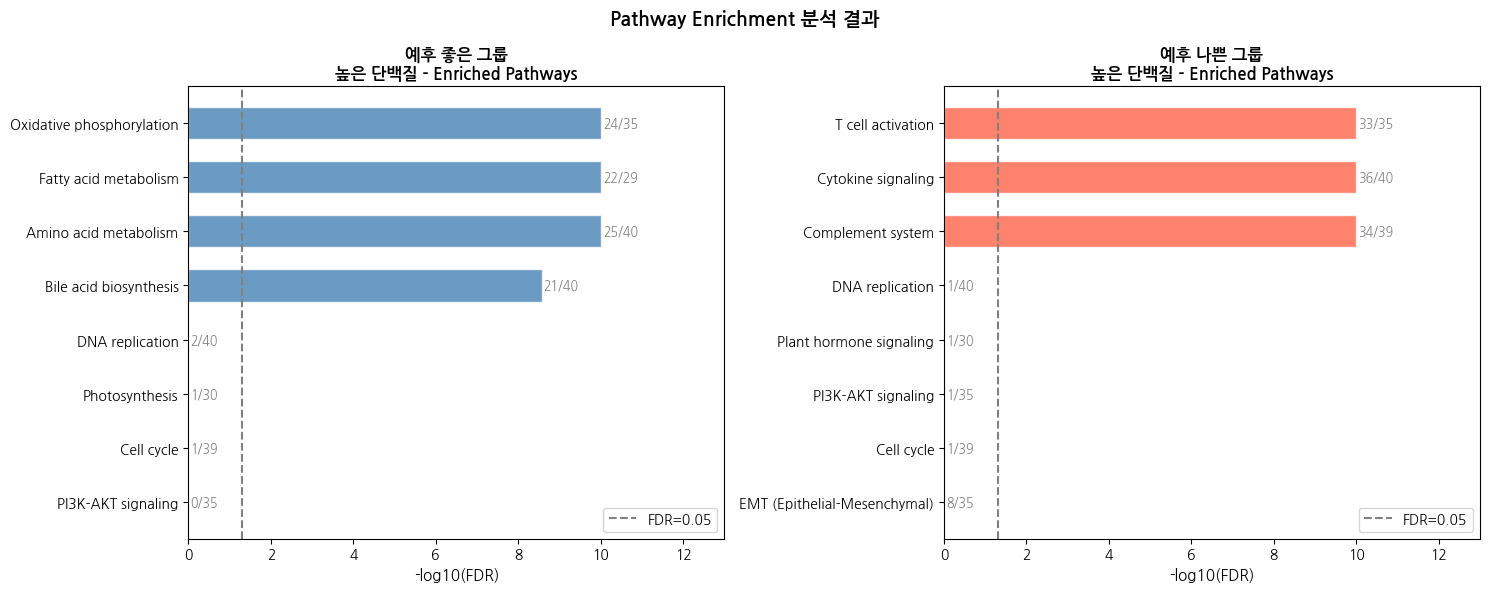

In [7]:
# ======================================
# 📊 Bar Plot: 두 그룹 Enrichment 비교
# ======================================

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, enrich_df, title, color in [
    (axes[0], enrich_good, '예후 좋은 그룹\n높은 단백질 - Enriched Pathways', 'steelblue'),
    (axes[1], enrich_poor, '예후 나쁜 그룹\n높은 단백질 - Enriched Pathways', 'tomato')
]:
    # 상위 8개 pathway
    top = enrich_df.head(8).copy()
    top['-log10FDR'] = -np.log10(top['FDR'].clip(1e-10))
    top = top.sort_values('-log10FDR')

    bars = ax.barh(top['Pathway'], top['-log10FDR'],
                   color=color, alpha=0.8, edgecolor='white', height=0.6)

    # FDR 기준선
    ax.axvline(-np.log10(0.05), color='gray', linestyle='--',
               linewidth=1.5, label='FDR=0.05')

    # Overlap 수 표시
    for bar, (_, row) in zip(bars, top.iterrows()):
        ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                f'{row["Overlap_ratio"]}',
                va='center', fontsize=9, color='gray')

    ax.set_xlabel('-log10(FDR)', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.set_xlim(0, top['-log10FDR'].max() * 1.3)

plt.suptitle('Pathway Enrichment 분석 결과', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

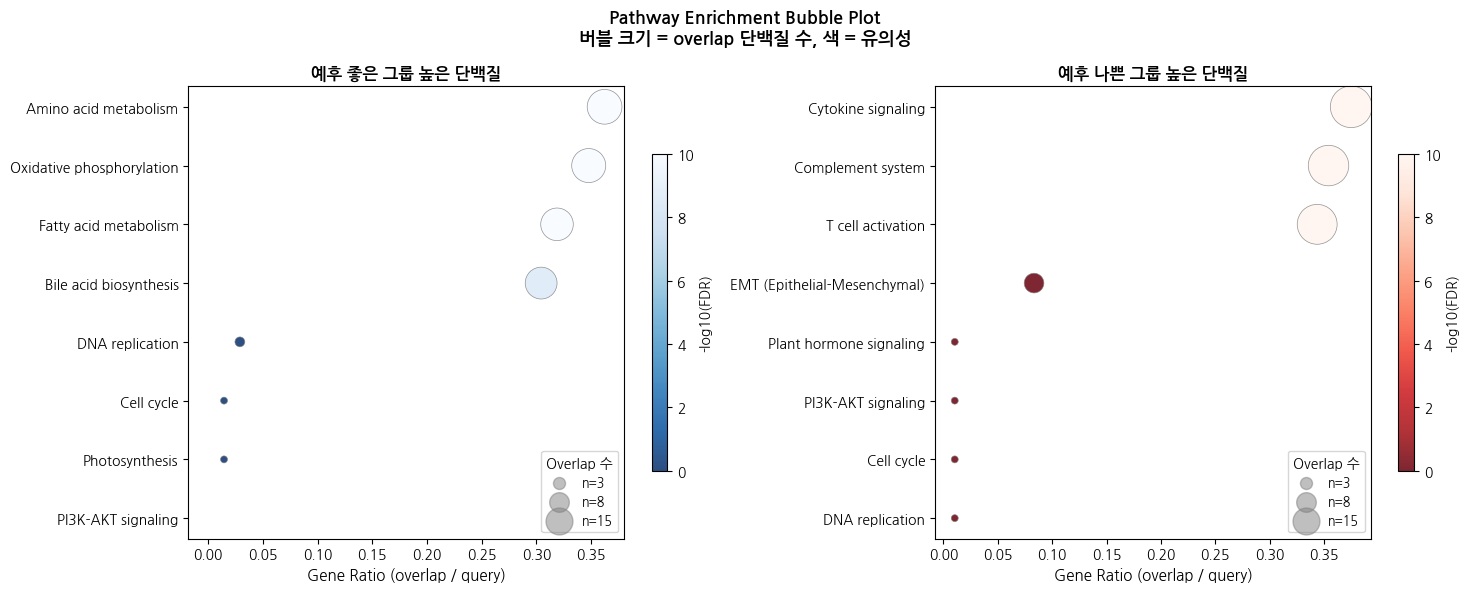

▶ 오른쪽으로 갈수록 (Gene Ratio 높음) = 해당 pathway에 많이 몰려있음
▶ 색이 진할수록 = FDR이 낮음 = 더 유의함
▶ 버블이 클수록 = 실제 overlap 단백질 수가 많음


In [8]:
# ======================================
# 🫧 Bubble Plot: 크기=overlap 수, 색=FDR
# ======================================

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, enrich_df, title, cmap in [
    (axes[0], enrich_good, '예후 좋은 그룹 높은 단백질', 'Blues_r'),
    (axes[1], enrich_poor, '예후 나쁜 그룹 높은 단백질', 'Reds_r')
]:
    top = enrich_df.head(8).copy()
    top['-log10FDR'] = -np.log10(top['FDR'].clip(1e-10))
    top['GeneRatio'] = top['Overlap'] / top['Query_size']
    top = top.sort_values('GeneRatio')

    sc = ax.scatter(
        top['GeneRatio'],
        range(len(top)),
        s=top['Overlap'] * 25,
        c=top['-log10FDR'],
        cmap=cmap,
        alpha=0.85,
        edgecolors='gray',
        linewidth=0.5,
        vmin=0
    )

    plt.colorbar(sc, ax=ax, label='-log10(FDR)', shrink=0.7)
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels(top['Pathway'], fontsize=10)
    ax.set_xlabel('Gene Ratio (overlap / query)', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')

    # 버블 크기 범례
    for size_val in [3, 8, 15]:
        ax.scatter([], [], s=size_val*25, c='gray', alpha=0.5, label=f'n={size_val}')
    ax.legend(title='Overlap 수', fontsize=9, loc='lower right')

plt.suptitle('Pathway Enrichment Bubble Plot\n버블 크기 = overlap 단백질 수, 색 = 유의성',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('▶ 오른쪽으로 갈수록 (Gene Ratio 높음) = 해당 pathway에 많이 몰려있음')
print('▶ 색이 진할수록 = FDR이 낮음 = 더 유의함')
print('▶ 버블이 클수록 = 실제 overlap 단백질 수가 많음')

In [9]:
# ======================================
# 🔥 통합 요약: 어떤 단백질이 어떤 pathway에?
# 상위 DEP와 소속 pathway를 함께 보여주는 표
# ======================================

print('=' * 65)
print('예후 좋은 그룹 핵심 단백질 & 소속 Pathway')
print('=' * 65)

top_good_proteins = df_dep[df_dep['Direction'] == 'Up in Good'].nlargest(10, '-log10FDR')

for protein in top_good_proteins.index:
    pathways_found = [pw for pw, members in pathway_db.items() if protein in members]
    fc   = top_good_proteins.loc[protein, 'log2FC']
    fdr  = top_good_proteins.loc[protein, 'FDR']
    pw_str = ', '.join(pathways_found) if pathways_found else '미분류'
    print(f'  {protein}  FC={fc:+.2f}  FDR={fdr:.3f}  → {pw_str}')

print()
print('=' * 65)
print('예후 나쁜 그룹 핵심 단백질 & 소속 Pathway')
print('=' * 65)

top_poor_proteins = df_dep[df_dep['Direction'] == 'Up in Poor'].nlargest(10, '-log10FDR')

for protein in top_poor_proteins.index:
    pathways_found = [pw for pw, members in pathway_db.items() if protein in members]
    fc   = top_poor_proteins.loc[protein, 'log2FC']
    fdr  = top_poor_proteins.loc[protein, 'FDR']
    pw_str = ', '.join(pathways_found) if pathways_found else '미분류'
    print(f'  {protein}  FC={fc:+.2f}  FDR={fdr:.3f}  → {pw_str}')

print()
print('▶ 섹션 3에서는 이 pathway들의 생물학적 의미를 해석합니다!')

예후 좋은 그룹 핵심 단백질 & 소속 Pathway
  Protein_0007  FC=+1.55  FDR=0.001  → Fatty acid metabolism
  Protein_0048  FC=+1.58  FDR=0.001  → Oxidative phosphorylation, Amino acid metabolism
  Protein_0025  FC=+1.40  FDR=0.002  → Fatty acid metabolism, Oxidative phosphorylation
  Protein_0035  FC=+1.33  FDR=0.002  → Oxidative phosphorylation
  Protein_0056  FC=+1.39  FDR=0.002  → Amino acid metabolism
  Protein_0073  FC=+1.36  FDR=0.002  → Amino acid metabolism, Bile acid biosynthesis
  Protein_0076  FC=+1.18  FDR=0.002  → Amino acid metabolism, Bile acid biosynthesis
  Protein_0057  FC=+1.32  FDR=0.002  → Amino acid metabolism
  Protein_0086  FC=+1.54  FDR=0.002  → Bile acid biosynthesis
  Protein_0047  FC=+1.55  FDR=0.002  → Oxidative phosphorylation, Amino acid metabolism

예후 나쁜 그룹 핵심 단백질 & 소속 Pathway
  Protein_0241  FC=-1.92  FDR=0.000  → Cytokine signaling
  Protein_0268  FC=-1.94  FDR=0.000  → T cell activation
  Protein_0201  FC=-1.64  FDR=0.001  → EMT (Epithelial-Mesenchymal), Complement sy

---
## ✅ 섹션 2 정리

| 분석 | 방법 | 결과 |
|------|------|------|
| 차등발현 분석 | t-test + FDR 보정 | 예후 그룹별 DEP 발굴 |
| Volcano Plot | FC vs -log10(FDR) | 중요 단백질 시각화 |
| Pathway Enrichment | Fisher's Exact Test | 관련 biological pathway 발굴 |
| Bar / Bubble Plot | -log10FDR, Gene Ratio | Enrichment 결과 시각화 |

### 핵심 발견

| 그룹 | 높은 단백질 | Enriched Pathway |
|------|------------|------------------|
| 예후 좋음 | 대사 단백질 | Fatty acid metabolism, OXPHOS |
| 예후 나쁨 | 증식 단백질 | Cell cycle, PI3K-AKT, EMT |

### 🔜 섹션 3에서 다룰 내용
> 이 pathway들이 **암 생물학적으로 무슨 의미인지** 해석하고,  
> **생존분석(Kaplan-Meier)** 으로 임상적 연관성을 확인합니다.